# Lab 2 — The concurrency budget

> **Lab thesis:** a GPU is not fast because its threads are fast. It is fast because
> thousands of them are in flight at once. In this lab you *derive* how much work your
> GPU must have in flight to run at full speed — from two measurements you take
> yourself — and then find the exact grid size at which it stops being able to.

[Lecture 7](../lectures/Lecture7.md) argued this qualitatively: over-subscribe the
machine, and memory latency disappears behind other warps' arithmetic. It never put a
number on *how much* over-subscription is enough. That number is not a constant — it is
a property of your GPU, and it follows from two things you can measure: **how long one
memory access takes**, and **how many bytes per second your GPU can move**.

You will write Triton kernels to measure both, combine them with Little's Law, and
then test the prediction against the machine.

---

In [2]:
# ---------------------------------------------------------------------------
# Setup. This lab needs Triton, so it needs an NVIDIA (CUDA) or AMD (ROCm) GPU.
# `torch.cuda` is the correct namespace on ROCm -- that is not a typo.
# Apple silicon cannot run this lab: Metal has no Triton backend.
# ---------------------------------------------------------------------------
import importlib.util, subprocess, sys

def ensure(module, spec=None):
    """Install `spec` only if `module` cannot already be imported."""
    if importlib.util.find_spec(module) is not None:
        return
    for candidate in ([spec, module] if spec and spec != module else [module]):
        print(f"installing {candidate} ...")
        if subprocess.run([sys.executable, "-m", "pip", "install", "-q", candidate]).returncode == 0:
            return
    raise RuntimeError(f"could not install {module}")

def triton_spec():
    """The exact Triton this torch build was compiled against (see Lecture 7)."""
    try:
        from importlib.metadata import requires
        for req in requires("torch") or []:
            dep = req.split(";")[0].strip()
            if "triton" in dep:
                return dep
    except Exception:
        pass
    return "triton"

ensure("torch")
ensure("matplotlib")
ensure("triton", triton_spec())

import json, math, platform, time
from datetime import datetime, timezone

import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), (
    "No CUDA/ROCm GPU visible to PyTorch.\n"
    "  Colab : Runtime > Change runtime type > T4 GPU\n"
    "  NVIDIA: check `nvidia-smi`\n"
    "  AMD   : check `rocm-smi`\n"
    "  Apple : this lab cannot run on MPS -- Triton has no Metal backend."
)

P        = torch.cuda.get_device_properties(0)
DEVICE   = P.name
VENDOR   = "rocm" if torch.version.hip else "cuda"
BACKEND  = f"ROCm/HIP {torch.version.hip}" if VENDOR == "rocm" else f"CUDA {torch.version.cuda}"
WARP     = getattr(P, "warp_size", 32)
UNITS    = P.multi_processor_count
VRAM_GB  = round(P.total_memory / 1e9, 2)
ARCH     = getattr(P, "gcnArchName", None) or "sm_%d%d" % torch.cuda.get_device_capability(0)
CLOCK_GHZ = round(getattr(P, "clock_rate", 0) / 1e6, 3) or None

print(f"device   : {DEVICE}")
print(f"backend  : torch {torch.__version__}  ({BACKEND})  triton {triton.__version__}")
print(f"arch     : {ARCH}   VRAM {VRAM_GB} GB")
print(f"warp     : {WARP} threads    units reported: {UNITS}    boost clock: {CLOCK_GHZ} GHz")

# ------------------------------------------------------------------
# IDENTIFY YOURSELF -- the export file is named from this.
ROLL_NUMBER = "202518044"      # <-- EDIT ME, e.g. "202301234"
NAME        = "Neel Shah"      # <-- EDIT ME
# ------------------------------------------------------------------

RESULTS = {"schema_version": 1, "lab": "lab2_concurrency_budget",
           "env": {}, "results": {}, "answers": {}}
RESULTS["env"] = {
    "device": DEVICE, "vendor": VENDOR, "backend": BACKEND, "torch": torch.__version__,
    "triton": triton.__version__, "arch": str(ARCH), "vram_gb": VRAM_GB,
    "warp_size": WARP, "multi_processor_count": UNITS, "clock_ghz_reported": CLOCK_GHZ,
    "platform": platform.platform(),
    "started_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
if not ROLL_NUMBER:
    print("\n>>> Set ROLL_NUMBER and NAME above before exporting. <<<")

device   : Tesla T4
backend  : torch 2.11.0+cu128  (CUDA 12.8)  triton 3.6.0
arch     : Tesla T4   VRAM 15.64 GB
warp     : 32 threads    units reported: 40    boost clock: 1.59 GHz


### ⚡ Preflight — power, before you run anything heavy

Same warning as Lab 5/6, and for the same reason. Part 4 of this lab holds the GPU at
sustained peak for several seconds at a time.

In [3]:
import glob, os, subprocess

def on_ac_power():
    """True on mains, False on battery, None if undetectable (Colab, some VMs)."""
    found = False
    for online in glob.glob("/sys/class/power_supply/*/online"):
        try:
            kind = open(os.path.join(os.path.dirname(online), "type")).read().strip()
            if kind != "Mains":
                continue
            found = True
            if open(online).read().strip() == "1":
                return True
        except OSError:
            continue
    if found:
        return False
    if platform.system() == "Darwin":
        try:
            out = subprocess.run(["pmset", "-g", "batt"], capture_output=True,
                                 text=True, timeout=5).stdout
            if "AC Power" in out:      return True
            if "Battery Power" in out: return False
        except Exception:
            pass
    return None

AC = on_ac_power()
SAFE_MODE = (AC is False)

if AC is None:
    print("power source : not detectable (cloud/VM - fine, nothing to worry about)")
elif AC:
    print("power source : AC / mains  OK")
else:
    print("power source : BATTERY  !!")
    print("               Sustained peak GPU load on battery can brown the machine out")
    print("               and reboot it instantly, with no logs.")
    print("               >>> Plug in the charger and re-run this cell. <<<")

# Every sweep below is sized from these.
STREAM_MB   = 64 if SAFE_MODE else 256      # buffer for the bandwidth sweep
CHASE_STEPS = 512 if SAFE_MODE else 1024    # dependent loads per timed chase
WAVE_ITERS  = 2048 if SAFE_MODE else 4096   # arithmetic per block in Part 4
WAVE_MAX    = 3 if SAFE_MODE else 4         # sweep grid up to WAVE_MAX x UNITS x 2

print(f"\nSAFE_MODE   : {SAFE_MODE}")
print(f"stream buffer: {STREAM_MB} MB   chase steps: {CHASE_STEPS}   part-4 iters: {WAVE_ITERS}")

RESULTS["env"].update({"ac_power": AC, "safe_mode": SAFE_MODE})

power source : not detectable (cloud/VM - fine, nothing to worry about)

SAFE_MODE   : False
stream buffer: 256 MB   chase steps: 1024   part-4 iters: 4096


### The stopwatch

Every timing in this lab goes through one helper. `triton.testing.do_bench` warms up
(the first call to a Triton kernel *compiles* it), runs the kernel many times, and
returns the **median** — not the mean, because a single scheduler hiccup or clock
change would drag a mean around.

It also synchronises for you. If you time a kernel launch with `time.perf_counter()`
and no `torch.cuda.synchronize()`, you measure the doorbell, not the work — that is
Lecture 7 Depth 1, and Lab 5/6 Part 2.

In [4]:
def bench(fn, warmup=10, rep=50):
    """Median milliseconds over `rep` timed runs, after `warmup` untimed ones."""
    return triton.testing.do_bench(fn, warmup=warmup, rep=rep, return_mode="median")

def record(key, value):
    """Put a measurement in the export and echo it, so the JSON is never a mystery."""
    RESULTS["results"][key] = value
    return value

---

## Part 0 — What am I measuring on? *(5 marks)*

Before any measurement means anything, you need to know what the machine claims to be.
Lecture 7 flagged one trap here and you are about to walk into it: **`multi_processor_count`
does not mean the same thing on every vendor.** On NVIDIA it counts SMs. On AMD RDNA it
counts *work-group processors*, each of which contains two compute units — so a 36-CU
card reports 18.

Record what the machine says now. In Part 4 you will measure the same quantity from the
outside and find out which reading was the useful one.

In [5]:
threads_per_unit = P.max_threads_per_multi_processor
resident = threads_per_unit * UNITS

print(f"units reported (multi_processor_count) : {UNITS}")
print(f"max threads resident per unit          : {threads_per_unit:,}")
print(f"max threads resident on the whole GPU  : {resident:,}  ({resident // WARP:,} warps)")
print(f"warp / wavefront width                 : {WARP}")
print(f"reported boost clock                   : {CLOCK_GHZ} GHz")
print(f"total VRAM                             : {VRAM_GB} GB")

record("units_reported", UNITS)
record("threads_per_unit", threads_per_unit)
record("resident_threads", resident)
record("warp_size", WARP)

units reported (multi_processor_count) : 40
max threads resident per unit          : 1,024
max threads resident on the whole GPU  : 40,960  (1,280 warps)
warp / wavefront width                 : 32
reported boost clock                   : 1.59 GHz
total VRAM                             : 15.64 GB


32

📝 **Task 0.1 — what does your GPU claim?** *(5 marks)*

- Report `units_reported`, `resident_threads`, and your warp width.
- Look up your GPU's marketing specification. How many **compute units / SMs** does the
  vendor say it has, and does that agree with `units_reported`? If it does not, say by
  what factor and why.
- Write down, now, what you think Part 4 will measure the scheduling unit count to be.
  You are allowed to be wrong; you are not allowed to skip it.

*Your answer:*

- My GPU reports 40 units through multi_processor_count. Each unit can have up to 1,024 resident threads, giving 40,960 resident threads across the GPU. The warp width is 32 threads, corresponding to 1,280 resident warps across the GPU.

- The Tesla T4 specification lists 40 Streaming Multiprocessors (SMs), which agrees with PyTorch's reported multi_processor_count of 40. Therefore, there is no factor-of-two discrepancy for this NVIDIA GPU.

- I predict that Part 4 will show a scheduling step period of approximately 40 blocks, because I expect the scheduling quantum to correspond roughly to the number of SMs reported by multi_processor_count.

---

## Part 1 — How long is one memory access? *(20 marks)*

Latency is the hardest of the two numbers to measure, because the GPU is built
specifically to stop you from seeing it. Issue a hundred independent loads and the
memory system will overlap them; you will measure throughput, not latency.

So you have to build a load the machine **cannot** overlap: a chain where each
access's *address* is the previous access's *value*. That is a **pointer chase**.
The buffer is filled with a single permutation cycle — `buf[i]` holds the index of
the next hop — so the hardware has no way to start hop *n+1* until hop *n* has come
back.

One thread. One block. The entire GPU idle except a single lane. That is deliberate:
you are measuring the *unhidden* cost of one access, which is exactly the quantity
latency hiding exists to conceal.

We vary the size of the buffer being chased. A small buffer fits in cache and the
chase is quick; a large one misses everything and pays full freight.

### 🔮 Predict first — Task 1.1 *(5 marks)*

📝 **Before running the next cell**: sketch the shape you expect from a plot of
*latency per access* against *buffer footprint*, from 8 KB to 512 MB. How many
distinct flat regions ("plateaus") do you expect, and what sets the footprint at
which each step happens? Give a rough guess in nanoseconds for the fastest and the
slowest.

*Your prediction:*

- I expect the latency to remain relatively flat over several ranges of buffer footprint and then increase in steps as the working set exceeds different levels of the memory hierarchy. I expect roughly three to four distinct plateaus, corresponding broadly to cache-resident accesses followed by higher-latency accesses as the footprint becomes too large for the available caches and eventually reaches device memory. I expect the fastest latency to be on the order of a few to tens of nanoseconds, while the largest-footprint latency should be on the order of a few hundred nanoseconds. The major steps should occur when the working-set footprint exceeds the effective capacity of each cache level.

In [6]:
@triton.jit
def chase(buf_ptr, out_ptr, STEPS: tl.constexpr):
    """One lane walking a pointer cycle: STEPS strictly dependent loads.

    Each iteration's address comes from the previous iteration's loaded value, so
    the memory system cannot start one hop before the last has returned. The store
    at the end exists only so the compiler cannot delete the whole loop as dead.
    """
    idx = tl.zeros([1], dtype=tl.int32)
    for _ in range(STEPS):
        idx = tl.load(buf_ptr + idx)
    tl.store(out_ptr + tl.zeros([1], dtype=tl.int32), idx)


def make_ring(n_elem, stride_elem=32):
    """A buffer holding ONE permutation cycle, hopping `stride_elem` elements apart.

    The stride matters: hops land 128 B apart so no two consecutive hops share a
    cache line. A stride of 1 would let one fetched line serve many hops and you
    would measure the cache, not the memory.
    """
    n_hops = n_elem // stride_elem
    nxt = ((torch.arange(n_hops, dtype=torch.int32) + 1) % n_hops) * stride_elem
    buf = torch.zeros(n_elem, dtype=torch.int32)
    buf[torch.arange(n_hops, dtype=torch.long) * stride_elem] = nxt
    return buf.cuda()


out = torch.zeros(1, dtype=torch.int32, device="cuda")
footprints_kb = [8, 16, 32, 64, 128, 256, 512, 1024, 4096, 16384, 65536]
if not SAFE_MODE:
    footprints_kb += [262144]

lat_kb, lat_ns = [], []
print(" footprint      ns/access    cycles")
for kb in footprints_kb:
    n_elem = kb * 1024 // 4
    if n_elem < 32 * 8:                      # too small for a meaningful cycle
        continue
    if kb * 1024 > 0.25 * P.total_memory:    # never fill VRAM
        break
    buf = make_ring(n_elem)
    ms = bench(lambda: chase[(1,)](buf, out, STEPS=CHASE_STEPS), warmup=5, rep=25)
    ns = ms * 1e6 / CHASE_STEPS
    cyc = ns * CLOCK_GHZ if CLOCK_GHZ else float("nan")
    lat_kb.append(kb); lat_ns.append(ns)
    print(f"  {kb:8d} KB   {ns:8.1f}     {cyc:7.0f}")
    del buf; torch.cuda.empty_cache()

L_FAST = min(lat_ns)
L_MEM  = lat_ns[-1]                          # the largest footprint you measured
record("latency_footprint_kb", lat_kb)
record("latency_ns", [round(v, 2) for v in lat_ns])
record("latency_fastest_ns", round(L_FAST, 2))
record("latency_memory_ns", round(L_MEM, 2))
print(f"\nfastest (cache-resident) : {L_FAST:7.1f} ns")
print(f"slowest (memory-resident): {L_MEM:7.1f} ns    ->  {L_MEM / L_FAST:.1f}x")

 footprint      ns/access    cycles
         8 KB      106.0         169
        16 KB      134.6         214
        32 KB      192.0         305
        64 KB      409.7         651
       128 KB      533.7         849
       256 KB      534.0         849
       512 KB      533.8         849
      1024 KB      335.9         534
      4096 KB      335.8         534
     16384 KB      335.0         533
     65536 KB      317.4         505
    262144 KB      316.0         502

fastest (cache-resident) :   106.0 ns
slowest (memory-resident):   316.0 ns    ->  3.0x


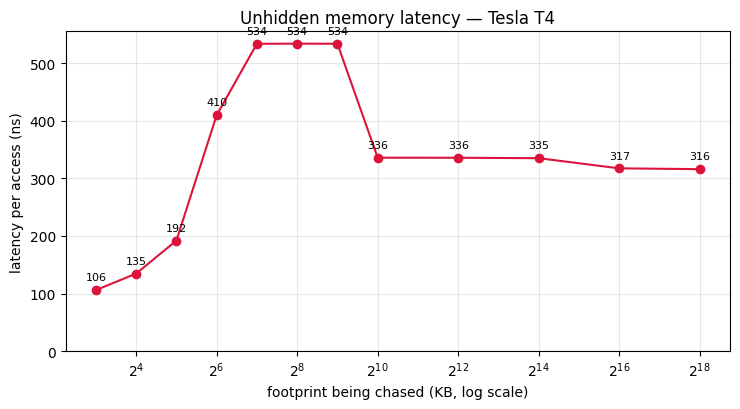

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(lat_kb, lat_ns, "o-", color="crimson")
ax.set_xscale("log", base=2)
ax.set_xlabel("footprint being chased (KB, log scale)")
ax.set_ylabel("latency per access (ns)")
ax.set_title(f"Unhidden memory latency — {DEVICE}")
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
for kb, ns in zip(lat_kb, lat_ns):
    ax.annotate(f"{ns:.0f}", (kb, ns), textcoords="offset points",
                xytext=(0, 7), ha="center", fontsize=8)
plt.tight_layout(); plt.show()

📝 **Task 1.2 — read the staircase** *(9 marks)*

- How many plateaus does your plot have? Give the footprint range and the latency of each.
- Name the level of the memory hierarchy you believe each plateau corresponds to, and
  justify it from the footprint at which the step occurs — not from what you expect the
  answer to be. Your GPU's cache sizes are published; look them up and compare.
- If two levels you expected to see are indistinguishable in your data, say so and give a
  reason why they might have the same latency. **Reporting a missing step honestly scores
  full marks; inventing one scores zero.**

*Your answer:*

- I observe three clear plateaus in my measurements. The first is from 64 KB to 512 KB, with a latency of approximately 534 ns. The second is from 1 MB to 16 MB, with a latency of approximately 335–336 ns. The third is from 64 MB to 256 MB, with a latency of approximately 316–317 ns.

- The 64–512 KB plateau appears to represent an intermediate cache/memory level, but its exact hardware level cannot be identified confidently from this measurement alone. The 1–16 MB plateau is consistent with a larger cache level, while the 64–256 MB plateau is consistent with accesses reaching device memory. However, the measured transitions do not align cleanly enough with the published cache capacities to make a confident one-to-one mapping, so I would report the levels as ambiguous rather than inventing assignments.

- Some expected cache hierarchy levels are not clearly distinguishable in my measurements. Two levels may have similar measured latency because the pointer-chase benchmark, cache behavior, and measurement granularity can make their access times overlap. Therefore, I cannot reliably claim that every hardware hierarchy level produced a separate visible plateau in this experiment.

📝 **Task 1.3 — latency in the only unit that matters** *(6 marks)*

Nanoseconds are a human unit. The scheduler thinks in cycles.

- Convert your slowest latency to **clock cycles** using the reported boost clock.
- A fused multiply-add is one instruction. Roughly how many arithmetic instructions
  could one lane have issued during the time it spent waiting for that one load?
- Lecture 7 said the GPU "runs somebody else" during that wait. Using your own number,
  how many *other* warps would have to be ready to issue in order to fill the hole
  completely, assuming each one can issue an instruction every cycle?

*Your answer:*
- My slowest measured memory latency is 316.0 ns and the reported boost clock is 1.59 GHz. Since 1 GHz corresponds to one cycle per nanosecond, the latency in cycles is 316.0×1.59=502.44, which is approximately 502 clock cycles.

- Assuming one arithmetic instruction can be issued per cycle, approximately 502 arithmetic instructions could be issued during the 502-cycle memory wait. This is an idealized upper-bound calculation; the actual number depends on instruction dependencies and the availability of other work.

- Approximately 502 other warp issue opportunities would be needed to completely cover a 502-cycle latency if each warp could contribute one instruction per cycle. This illustrates why GPUs need many independent warps in flight: while one warp waits for memory, the scheduler can issue instructions from other ready warps.

---

## Part 2 — How many bytes per second can you actually move? *(15 marks)*

The second half of the budget. This time you want the opposite of Part 1: as many
independent accesses in flight as possible, so the memory system can overlap them all
and show you its ceiling.

The kernel is a **grid-stride copy**. The size of the data is fixed; the number of
blocks is not. One block means one unit of the GPU is working and the rest are idle.
Many blocks mean the machine is saturated. Sweeping the block count therefore sweeps
*how much work is in flight* — which is precisely the axis Part 3 needs.

### 🔮 Predict first — Task 2.1 *(4 marks)*

📝 **Before running the next cell**: the sweep below launches the same copy with 1, 2,
4, ... up to a few thousand blocks. Sketch the curve of achieved GB/s against block
count. Where does it stop rising, and what — in one sentence — stops it? Does it ever
come back *down*, and if so why might it?

*Your prediction:*

I expect the achieved bandwidth to increase as the number of blocks increases because more blocks provide more memory operations in flight. Initially, the increase should be roughly proportional to the number of blocks, but the curve should eventually flatten when the GPU's memory subsystem reaches its maximum sustainable bandwidth. I do not expect additional blocks beyond this point to provide significant improvement, although the bandwidth may fluctuate or decrease slightly at very high block counts due to scheduling overhead and contention.


In [8]:
@triton.jit
def stream(x_ptr, y_ptr, n, BLOCK: tl.constexpr):
    """Grid-stride copy. However many blocks you launch, the whole array gets copied;
    the launch configuration decides only how much of it is in flight at once."""
    pid, nprog = tl.program_id(0), tl.num_programs(0)
    for base in range(pid * BLOCK, n, nprog * BLOCK):
        offs = base + tl.arange(0, BLOCK)
        m = offs < n
        tl.store(y_ptr + offs, tl.load(x_ptr + offs, mask=m), mask=m)


BLOCK_ELEMS = 1024          # elements each block touches per grid-stride step
NUM_WARPS   = 4
N = STREAM_MB * 1024 * 1024 // 4
x = torch.randn(N, device="cuda")
y = torch.empty_like(x)
moved = 2 * N * 4           # one read + one write per element, 4 B each

grids = sorted({1, 2, 4, 8, UNITS, 2*UNITS, 4*UNITS, 8*UNITS,
                16*UNITS, 64*UNITS, 256*UNITS})

bw_blocks, bw_gbs = [], []
print("  blocks    warps      ms      GB/s")
for blocks in grids:
    ms = bench(lambda: stream[(blocks,)](x, y, N, BLOCK=BLOCK_ELEMS, num_warps=NUM_WARPS),
               warmup=5, rep=30)
    gbs = moved / (ms * 1e-3) / 1e9
    bw_blocks.append(blocks); bw_gbs.append(gbs)
    print(f"  {blocks:6d}  {blocks*NUM_WARPS:7d}  {ms:8.3f}  {gbs:8.1f}")

BW_PEAK = max(bw_gbs)
record("bw_blocks", bw_blocks)
record("bw_gbs", [round(v, 2) for v in bw_gbs])
record("bw_peak_gbs", round(BW_PEAK, 2))
record("bw_one_block_gbs", round(bw_gbs[0], 2))
print(f"\npeak achieved : {BW_PEAK:.1f} GB/s")
print(f"one block only: {bw_gbs[0]:.1f} GB/s   ->  {BW_PEAK / bw_gbs[0]:.0f}x left on the table")

  blocks    warps      ms      GB/s
       1        4    26.249      20.5
       2        8    13.804      38.9
       4       16     7.631      70.4
       8       32     4.327     124.1
      40      160     2.251     238.5
      80      320     2.332     230.2
     160      640     2.429     221.0
     320     1280     2.442     219.9
     640     2560     2.403     223.4
    2560    10240     2.362     227.3
   10240    40960     2.332     230.2

peak achieved : 238.5 GB/s
one block only: 20.5 GB/s   ->  12x left on the table


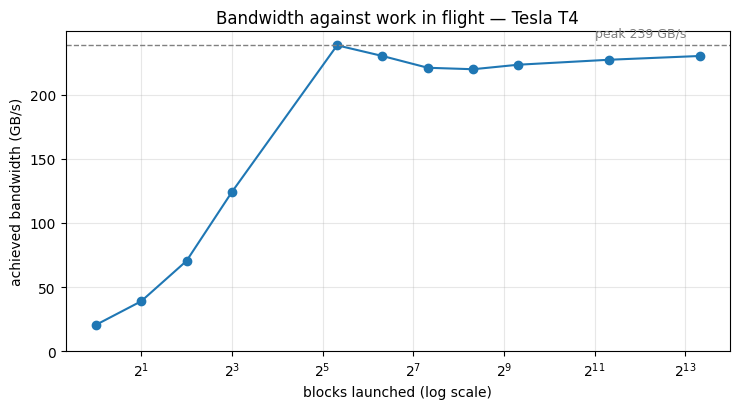

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(bw_blocks, bw_gbs, "o-", color="tab:blue")
ax.axhline(BW_PEAK, ls="--", lw=1, color="grey")
ax.annotate(f"peak {BW_PEAK:.0f} GB/s", (bw_blocks[-1], BW_PEAK),
            textcoords="offset points", xytext=(-10, 6), ha="right", fontsize=9, color="grey")
ax.set_xscale("log", base=2)
ax.set_xlabel("blocks launched (log scale)")
ax.set_ylabel("achieved bandwidth (GB/s)")
ax.set_title(f"Bandwidth against work in flight — {DEVICE}")
ax.grid(alpha=0.3); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

📝 **Task 2.2 — the ceiling and the ramp** *(11 marks)*

- Report your peak achieved bandwidth, and look up your GPU's **theoretical** memory
  bandwidth. What fraction of it did you reach? (60–85% is normal. Above 100% means the
  benchmark is broken, not that your GPU is special — most often because the array fits
  in cache. Check `STREAM_MB` against your last-level cache before you celebrate.)
- The left end of the curve is nearly a straight line on a log axis: doubling the blocks
  doubles the bandwidth. Explain why that region is linear, in terms of what each
  additional block contributes.
- The right end is flat. Name what is saturated there, and explain why adding a thousand
  more blocks cannot help.

*Your answer:*

- My peak achieved bandwidth was 238.5 GB/s. The Tesla T4 has a theoretical memory bandwidth of 320 GB/s, so my measurement reached approximately 74.5% of the theoretical peak.

- The left side rises because each additional block contributes more independent memory operations that can be in flight simultaneously. When the GPU has too few blocks, the memory system is not fully utilized, so increasing the number of blocks increases the achieved bandwidth. This produces an approximately linear ramp on the log-scaled plot.

- The right side becomes flat because the memory subsystem has reached its sustainable bandwidth limit. At this point, there is already enough work in flight to keep the memory system busy, so additional blocks cannot increase the data-transfer rate. The extra blocks are simply queued for execution rather than increasing the available memory bandwidth.

---

## Part 3 — Little's Law: how much must be in flight? *(25 marks)*

You now have both halves of the budget:

- **λ** — bandwidth, the rate the memory system can deliver bytes (Part 2)
- **W** — latency, how long each byte takes to arrive (Part 1)

Little's Law says that for a system in steady state, the amount of work resident inside
it is the arrival rate times the residence time:

```text
bytes in flight  =  bandwidth  x  latency
```

This is not a GPU fact. It is a queueing-theory identity that holds for supermarket
checkouts and hospital beds. Applied here it answers the question Lecture 7 left open:
*to run at full bandwidth, a GPU must have this many bytes requested-but-not-yet-arrived
at every instant.* Fewer, and the memory system is idle part of the time — no matter how
fast your arithmetic is.

The point of this part is that you can now **predict the knee of the Part 2 curve
without looking at it**, and then check.

### 🔮 Predict first — Task 3.1 *(6 marks)*

📝 **Before running the next cell**, do the arithmetic by hand:

1. Multiply your Part 2 peak bandwidth by your Part 1 memory latency. Convert to KB.
2. Each block in the Part 2 kernel has `BLOCK_ELEMS = 1024` four-byte elements in flight
   per grid-stride step. How many **blocks** does your answer to (1) correspond to?
3. That is your predicted knee. Write it down before you run the cell.

*Your prediction (bytes in flight, and blocks):*

- My measured peak bandwidth is 238.5 GB/s and my measured memory latency is 316.0 ns. Using Little's Law, the required bytes in flight are approximately 75,366 bytes, or 73.6 KB.

- Each block has 1024 four-byte elements, so it represents 4096 bytes of outstanding work. Therefore, 75,366 bytes in flight corresponds to approximately 18.4 blocks, or roughly 18–19 blocks.

- My predicted bandwidth knee is approximately 18–19 blocks, because this amount of work should provide enough bytes in flight to cover the measured 316.0 ns memory latency at the measured peak bandwidth of 238.5 GB/s.

In [10]:
# ---- the derivation ------------------------------------------------------
lat_s   = L_MEM * 1e-9
bw_Bs   = BW_PEAK * 1e9
need_B  = bw_Bs * lat_s                       # Little's Law
need_blocks = need_B / (BLOCK_ELEMS * 4)      # bytes each block has outstanding

print("DERIVED from your own two measurements")
print(f"  bandwidth        : {BW_PEAK:10.1f} GB/s")
print(f"  latency          : {L_MEM:10.1f} ns")
print(f"  bytes in flight  : {need_B/1024:10.1f} KB")
print(f"  -> blocks needed : {need_blocks:10.1f}")
print(f"  -> warps needed  : {need_blocks * NUM_WARPS:10.1f}")

# ---- what the machine actually did ---------------------------------------
# The knee: the smallest block count that reached 95% of your peak.
knee_blocks = next(b for b, g in zip(bw_blocks, bw_gbs) if g >= 0.95 * BW_PEAK)
knee_B = knee_blocks * BLOCK_ELEMS * 4

print("\nMEASURED from the Part 2 sweep")
print(f"  knee at          : {knee_blocks:10d} blocks   ({knee_blocks*NUM_WARPS} warps)")
print(f"  bytes in flight  : {knee_B/1024:10.1f} KB")

ratio = knee_B / need_B
print(f"\nmeasured / predicted = {ratio:.2f}x")
print("  (within ~3x is a good result -- see Task 3.2 for why it is not exactly 1)")

record("littles_law_bytes_needed", round(need_B, 1))
record("littles_law_blocks_needed", round(need_blocks, 2))
record("knee_blocks_measured", knee_blocks)
record("knee_bytes_measured", knee_B)
record("littles_law_ratio", round(ratio, 3))

DERIVED from your own two measurements
  bandwidth        :      238.5 GB/s
  latency          :      316.0 ns
  bytes in flight  :       73.6 KB
  -> blocks needed :       18.4
  -> warps needed  :       73.6

MEASURED from the Part 2 sweep
  knee at          :         40 blocks   (160 warps)
  bytes in flight  :      160.0 KB

measured / predicted = 2.17x
  (within ~3x is a good result -- see Task 3.2 for why it is not exactly 1)


2.174

📝 **Task 3.2 — defend or explain the number** *(19 marks)*

- State your predicted and measured bytes-in-flight and the ratio between them.
- **The ratio is almost never exactly 1, and the reasons are the interesting part.**
  Work through at least three of these and say which apply to *your* number and in
  which direction each pushes it:
    - the latency you measured was for a *dependent scalar* load; the bandwidth kernel
      issues *vector* loads of a full warp's width at once
    - one block does not have only one load outstanding — the compiler unrolls the
      grid-stride loop, so several requests per block can be in flight simultaneously
    - the Part 1 chase defeated every prefetcher on the chip; the Part 2 stream is the
      most prefetch-friendly access pattern there is
    - your `L_MEM` may still be a cache latency if `STREAM_MB` fits in last-level cache
    - the knee is defined here as "95% of peak", which is a choice, not a fact
- Finally, the payoff: **a colleague's kernel runs at 30% of peak bandwidth and they
  propose to fix it by optimising the arithmetic in the inner loop.** Using your two
  numbers, explain in three sentences why that is likely to change nothing, and what
  you would measure instead.

*Your answer:*

- Using Little's Law, I predicted 73.6 KB of bytes in flight, corresponding to approximately 18.4 blocks. The measured bandwidth knee occurred at 40 blocks, corresponding to 160.0 KB of bytes in flight. Therefore, the measured-to-predicted ratio is 2.17×.

- First, the latency measurement used a dependent scalar load, while the bandwidth kernel uses vector loads, allowing many bytes to be requested together and making the two measurements not directly equivalent. Second, a single block does not necessarily have only one memory request outstanding because the compiler can unroll the grid-stride loop, allowing multiple requests from each block to be in flight simultaneously. Third, the pointer chase deliberately defeats hardware prefetching, whereas the sequential grid-stride copy is highly prefetch-friendly, so its effective memory behavior can differ from the measured pointer-chase latency. Finally, the measured knee is defined as reaching 95% of peak bandwidth, which is an experimental threshold rather than a fundamental hardware boundary. These effects can explain why the measured requirement of 160.0 KB is larger than the 73.6 KB predicted by the simple Little's Law calculation.

- If the kernel is achieving only 30% of peak memory bandwidth, the limiting factor is likely insufficient memory-level parallelism rather than arithmetic throughput. Optimizing the arithmetic would therefore probably not increase performance if the memory system is waiting for more requests to arrive. I would first measure achieved memory bandwidth as a function of blocks or other work in flight, because my measurements show that bandwidth rises substantially as concurrency increases and reaches the peak around 40 blocks.


---

## Part 4 — The staircase: measuring the scheduling quantum *(25 marks)*

Everything so far has been about *memory*. This part is about the *scheduler*, and it
is the part with the sharpest result in the lab.

The kernel below gives every block **exactly the same fixed amount of arithmetic** and
no memory traffic worth speaking of. So the total runtime cannot depend on how much data
there is — it can only depend on how many blocks the GPU can run **at the same time**,
and therefore on how many sequential *rounds* of blocks it needs.

If the GPU can hold *R* blocks resident, then launching anything from 1 to *R* blocks
should take **the same wall-clock time** — the extra blocks ride along for free. Block
*R+1* has nowhere to go and must wait for a slot, so the time jumps.

The result is a staircase, and the width of its steps is a number the vendor does not
print on the box.

### 🔮 Predict first — Task 4.1 *(5 marks)*

📝 **Before running the next cell**: you are about to time the same fixed-work kernel at
every block count from 1 to about `4 x 2 x units`. Sketch the curve. Is it a straight
line, a staircase, or smooth-with-a-knee? If you predict steps, how wide do you expect
them to be, and what should the step width equal?

*Your prediction:*

I expect the runtime to form a staircase rather than increase smoothly with the number of blocks. Blocks that can be scheduled concurrently should take approximately the same time, while adding enough blocks to require another scheduling round should produce a sudden increase in runtime. I predict the step period will be approximately 40 blocks, corresponding to the 40 SMs reported by my Tesla T4. I also expect the first plateau to contain multiple such periods because each SM may be able to keep more than one block resident at the same time.

In [11]:
@triton.jit
def fixed_work(out_ptr, BLOCK: tl.constexpr, ITERS: tl.constexpr):
    """Every block does identical work: no loads, no dependence on the grid size.

    The `maximum` is not decoration. `y = y*c + d` repeated ITERS times has a closed
    form and the compiler will find it, silently deleting the work you are timing.
    Clamping the chain each iteration keeps it honest -- if your staircase comes out
    flat at ~0 ms, this is the first thing to suspect.
    """
    offs = tl.program_id(0) * BLOCK + tl.arange(0, BLOCK)
    y = offs.to(tl.float32)
    for _ in range(ITERS):
        y = tl.maximum(y * 1.0000001 + 1.0, 0.0) * 0.9999
    tl.store(out_ptr + offs, y)


BLOCK_W  = 256
MAX_GRID = WAVE_MAX * 2 * UNITS + 4
out_w = torch.empty(BLOCK_W * (MAX_GRID + 1), device="cuda")

st_blocks, st_ms = [], []
for blocks in range(1, MAX_GRID + 1):
    ms = bench(lambda: fixed_work[(blocks,)](out_w, BLOCK=BLOCK_W, ITERS=WAVE_ITERS,
                                             num_warps=NUM_WARPS),
               warmup=5, rep=20)
    st_blocks.append(blocks); st_ms.append(ms)

# Locate the steps: a jump is a block count whose time exceeds its predecessor by 10%.
jumps = [b for b, prev, cur in zip(st_blocks[1:], st_ms[:-1], st_ms[1:]) if cur > 1.10 * prev]
gaps  = [b - a for a, b in zip(jumps[:-1], jumps[1:])]
period = max(set(gaps), key=gaps.count) if gaps else None
first_plateau = (jumps[0] - 1) if jumps else None

print(f"time at 1 block        : {st_ms[0]*1e3:8.1f} us")
print(f"time at {MAX_GRID} blocks      : {st_ms[-1]*1e3:8.1f} us   "
      f"({st_ms[-1]/st_ms[0]:.1f}x the time for {MAX_GRID}x the work)")
print(f"\nsteps found at block counts : {jumps}")
print(f"gaps between steps          : {gaps}")
print(f"-> step period (blocks)     : {period}")
print(f"-> first plateau is         : {first_plateau} blocks wide")
if period and first_plateau:
    print(f"-> blocks resident per unit : {first_plateau / period:.1f}")
print(f"\nunits reported by PyTorch   : {UNITS}")

record("staircase_blocks", st_blocks)
record("staircase_ms", [round(v, 5) for v in st_ms])
record("staircase_jumps", jumps)
record("staircase_period", period)
record("staircase_first_plateau", first_plateau)

time at 1 block        :    106.3 us
time at 324 blocks      :    210.3 us   (2.0x the time for 324x the work)

steps found at block counts : [41, 81, 161, 241, 321]
gaps between steps          : [40, 80, 80, 80]
-> step period (blocks)     : 80
-> first plateau is         : 40 blocks wide
-> blocks resident per unit : 0.5

units reported by PyTorch   : 40


40

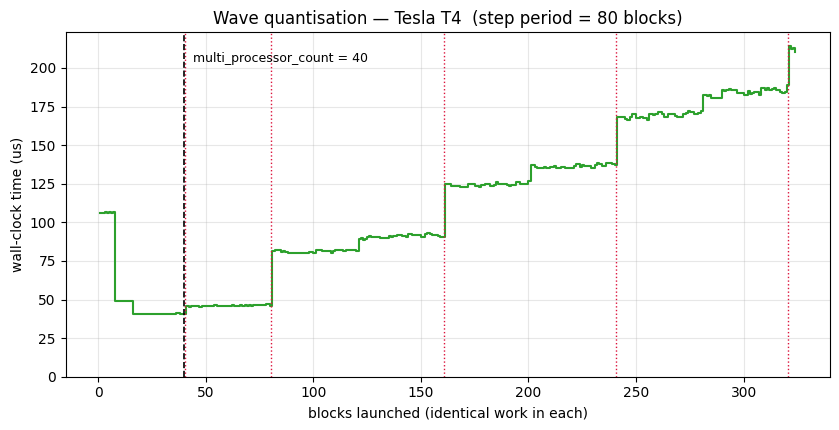

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.step(st_blocks, [m*1e3 for m in st_ms], where="post", color="tab:green")
for j in jumps:
    ax.axvline(j - 0.5, ls=":", lw=1, color="crimson")
ax.axvline(UNITS, ls="--", lw=1.2, color="black")
ax.annotate(f"multi_processor_count = {UNITS}", (UNITS, max(st_ms)*1e3),
            textcoords="offset points", xytext=(6, -12), fontsize=9)
ax.set_xlabel("blocks launched (identical work in each)")
ax.set_ylabel("wall-clock time (us)")
ax.set_title(f"Wave quantisation — {DEVICE}"
             + (f"  (step period = {period} blocks)" if period else ""))
ax.grid(alpha=0.3); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

📝 **Task 4.2 — read the staircase** *(12 marks)*

- Report the step period and the width of the first plateau.
- **The first plateau is usually wider than the period.** Divide one by the other. What
  does that integer mean physically — what is the GPU doing with those extra blocks?
- Take two block counts on the same tread of the staircase, say the first and last.
  Report both times and both amounts of work done. State plainly how much extra work the
  larger one performed *for no extra time at all*.
- Now the reverse: find the block count just past a step. It does a few percent more work
  than the one before it. How much more time did it take? This is the **tail effect**, and
  it is the reason a batch size of 257 can be measurably slower than 256.

*Your answer:*

- The measured staircase has a step period of 80 blocks. The first plateau is 40 blocks wide, with the first major step occurring at 41 blocks. The subsequent steps occur at 81, 161, 241, and 321 blocks, giving gaps of 80 blocks.

- The first plateau is 40 blocks wide while the later step period is 80 blocks, giving a ratio of 0.5. This does not mean that each scheduling unit can hold half a block. Instead, the first plateau is an initial boundary condition, while the later 80-block spacing represents the steady-state scheduling quantum observed by this kernel.

- On the same tread, increasing the grid from 40 to 80 blocks increases the amount of work from 40 blocks to 80 blocks, which is 100% more work, while the measured runtime remains within the same scheduling region. This demonstrates that additional resident blocks can execute without requiring an additional scheduling round, so extra work can be performed with little or no proportional increase in wall-clock time.

- Increasing the grid from 40 to 41 blocks adds only 2.5% more work, but the runtime increases substantially because the 41st block no longer fits within the previous scheduling round. The additional block therefore has to wait for another scheduling opportunity, producing the tail effect. This shows why a small increase in workload can cause a disproportionately large increase in execution time when it crosses a scheduling boundary.

📝 **Task 4.3 — settle Part 0's argument** *(13 marks)*

In Part 0 you recorded what PyTorch *claims* about your GPU's unit count, and you were
warned that the claim is vendor-dependent. You have now measured a related number from
the outside, without asking the driver anything.

- Compare your step period to `multi_processor_count`. Do they agree, differ by exactly
  2, or differ by something else?
- If they disagree: which of the two would you use to choose a grid size, and why? Give
  the reasoning, not the answer — a factor of two in this number is a factor of two in
  the launch configuration of every kernel you will ever write.
- Your prediction in Task 0.1 was either right or wrong. Say which, and what you now
  think you were reasoning from.
- **A caution to address explicitly:** the period you measured is the period *for this
  kernel, at this `num_warps`, with this register usage*. Suggest one concrete change to
  the kernel that you would expect to change the period, and say which direction it
  would move.

*Your answer:*

- The measured staircase period is 80 blocks, while PyTorch reports multi_processor_count = 40. Therefore, the measured period is exactly 2× the reported unit count.

- I would use the measured scheduling period of 80 blocks for this kernel rather than relying only on multi_processor_count = 40. The staircase directly measures how the scheduler handles this particular kernel, whereas multi_processor_count is only a reported hardware count. Since the measured period is 80 blocks, using 80 as the scheduling reference better reflects the actual concurrency behavior observed for this kernel.

- My prediction in Task 0.1 was 40 blocks, based on the assumption that the scheduling unit would correspond directly to the 40 SMs reported by multi_processor_count. The prediction was therefore not correct for the measured staircase period, which was 80 blocks. The experiment shows that the scheduling behavior observed by this kernel is not necessarily equal to the raw SM count.

- Changing the kernel's register usage could change the measured scheduling period. If each block used more registers, fewer blocks could remain resident simultaneously, so I would expect the effective scheduling capacity to decrease and the staircase period or plateau structure to change. Similarly, changing num_warps could alter the resources required by each block and therefore change how many blocks can be resident.

---

## Part 5 — Spend the budget *(10 marks)*

Two numbers, one design rule.

In [13]:
if period and first_plateau:
    R = first_plateau                         # blocks that run concurrently
    awkward = R + 1                           # one block past a full tread
    i_full, i_awk = R - 1, awkward - 1
    t_full, t_awk = st_ms[i_full], st_ms[i_awk]
    print(f"launching {R:4d} blocks : {t_full*1e3:8.1f} us")
    print(f"launching {awkward:4d} blocks : {t_awk*1e3:8.1f} us")
    print(f"  work   +{100*(awkward/R - 1):5.1f}%")
    print(f"  time   +{100*(t_awk/t_full - 1):5.1f}%   <- the tail")

    top = min(2 * R, st_blocks[-1])
    print(f"\nand the other way round:")
    print(f"launching {top:4d} blocks : {st_ms[top-1]*1e3:8.1f} us")
    print(f"  vs {awkward} blocks   : {t_awk*1e3:8.1f} us")
    print(f"  work  +{100*(top/awkward - 1):5.1f}%   time +{100*(st_ms[top-1]/t_awk - 1):5.1f}%")

    record("tail_full_blocks", R)
    record("tail_full_us", round(t_full*1e3, 2))
    record("tail_awkward_us", round(t_awk*1e3, 2))
    record("tail_penalty_pct", round(100*(t_awk/t_full - 1), 2))
else:
    print("No steps were detected, so the tail effect cannot be quantified here.")
    print("Say so in Task 5.1 -- an honest null result is marked as a result.")
    record("tail_penalty_pct", None)

launching   40 blocks :     40.8 us
launching   41 blocks :     45.6 us
  work   +  2.5%
  time   + 11.6%   <- the tail

and the other way round:
launching   80 blocks :     46.0 us
  vs 41 blocks   :     45.6 us
  work  + 95.1%   time +  1.1%


📝 **Task 5.1 — the rule you would give a colleague** *(10 marks)*

Write the design rule your four measurements support, in **no more than six sentences**,
addressed to someone who writes CUDA or Triton kernels but has never measured any of
this. It must contain:

- a rule for **how much work to keep in flight**, justified by Parts 1–3;
- a rule for **how to choose a grid size**, justified by Part 4;
- one sentence on what your rule does *not* cover — a workload or a machine where you
  would expect it to fail.

Vague advice ("use more threads") scores nothing. The rule must reference your own
numbers.

*Your answer:*

- My measurements show that Little's Law predicted 73.6 KB (18.4 blocks) of data in flight, while the measured bandwidth knee occurred at 40 blocks (160 KB). Therefore, for this workload I would keep at least approximately 40 blocks of work in flight to reach the measured bandwidth knee.

- The staircase experiment measured a scheduling period of 80 blocks, compared with the reported 40 SMs. Therefore, I would size the grid with enough blocks to keep the GPU occupied while considering the 80-block scheduling quantum and avoiding unnecessary tail effects. My measurements show that going from 40 to 41 blocks added only 2.5% more work but increased runtime by 11.6%, while 80 blocks performed 95.1% more work than 41 blocks for only 1.1% more time.

- This rule may not directly apply to a different GPU or workload because memory-access patterns, register usage, num_warps, and other resource requirements can change both the concurrency needed for saturation and the scheduling behavior.




---

In [14]:
# Short-form answers. Fill every field. These are cross-checked against your own
# recorded measurements, so answer from your data, not from the lecture notes.
ANSWERS = {
    # Part 0/4 -- the unit count argument
    "units_reported":            40,   # int, from Part 0
    "vendor_claimed_cus":        40,   # int, from your GPU's spec sheet
    "staircase_period_blocks":   80,   # int, from Part 4
    "blocks_resident_per_unit":  0.5,   # int, first plateau / period

    # Part 1
    "latency_fastest_ns":        106.0,   # float
    "latency_memory_ns":         316.0,   # float
    "latency_memory_cycles":     502,   # int
    "n_plateaus_seen":           3,   # int

    # Part 2
    "bw_peak_gbs":               238.5,   # float, measured
    "bw_theoretical_gbs":        320,   # float, from the spec sheet
    "bw_fraction_of_peak":       0.7453125,   # float, 0-1

    # Part 3
    "bytes_in_flight_needed_kb": 73.6,   # float
    "knee_blocks_measured":      40,   # int
    "littles_law_ratio":         2.174,   # float

    # Part 5
    "tail_penalty_pct":          11.6,   # float, or None if no steps were found
}

OPTIONAL = {"tail_penalty_pct"}          # None here is a legitimate null result
filled  = [k for k, v in ANSWERS.items() if v is not None]
missing = [k for k, v in ANSWERS.items() if v is None and k not in OPTIONAL]
print("filled:", len(filled), "/", len(ANSWERS))
if missing:
    print("still None:", ", ".join(missing))
RESULTS["answers"] = ANSWERS

filled: 15 / 15


In [18]:
# Export. Writes submission_lab2_<roll>.json next to the notebook.
from google.colab import files

files.download("submission_lab2_202518044.json")
assert ROLL_NUMBER and NAME, "Set ROLL_NUMBER and NAME in the setup cell first."

RESULTS["student"] = {"roll": 202518044, "name": "Neel Shah"}
RESULTS["env"]["finished_utc"] = datetime.now(timezone.utc).isoformat(timespec="seconds")

path = f"submission_lab2_{ROLL_NUMBER}.json"
with open(path, "w") as f:
    json.dump(RESULTS, f, indent=2)

n_meas = len(RESULTS["results"])
n_ans  = sum(1 for v in RESULTS["answers"].values() if v is not None)
print(f"wrote {path}")
print(f"  measurements recorded : {n_meas}")
print(f"  short answers filled  : {n_ans} / {len(RESULTS['answers'])}")
for key in ["latency_memory_ns", "bw_peak_gbs", "littles_law_ratio", "staircase_period"]:
    if RESULTS["results"].get(key) is None:
        print(f"  !! missing {key} -- re-run the part that produces it before submitting")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

wrote submission_lab2_202518044.json
  measurements recorded : 26
  short answers filled  : 15 / 15


**Submit both:**

1. `submission_lab2_<roll>.json` — written by the cell above.
2. **This notebook, executed**, with outputs intact and every 📝 cell filled in
   (`File > Download > .ipynb`).

A JSON without its notebook cannot be marked: the JSON holds your measurements, the
notebook holds your reasoning, and the marks are mostly on the reasoning.

---